<a href="https://colab.research.google.com/github/rohitium/memory-mosaics-jax/blob/master/notebooks/memory_mosaics_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Memory Mosaics vs GPT-2: Fig. 7, one block

Trains both 1-block models with the paper's model, data and optimizer, and plots training and validation
loss as in the 1-block panel of Fig. 7 ([arXiv:2405.06394v3](https://arxiv.org/abs/2405.06394v3)).

The default quick run takes ~15 min on a Colab TPU or GPU (fastest: v6e-1 TPU): sanity checks, then batch 32
and as many steps as fit `TRAIN_MINUTES`. That is the start of training (the paper's curves begin after ~1B tokens), so compare
trends, not values. `PAPER_RUN = True` uses the full recipe: 21B tokens per model.

In [1]:
import warnings
warnings.filterwarnings("ignore", "Transparent hugepages")  # harmless TPU startup notice
!pip install -q tiktoken py7zr multivolumefile
!test -d memory-mosaics-jax || git clone -q https://github.com/rohitium/memory-mosaics-jax.git
import sys
sys.path.insert(0, "memory-mosaics-jax/src")
import jax
print(jax.devices())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 16.3 MB/s eta 0:00:00
[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


In [2]:
import dataclasses, os, time
import numpy as np
from mm_jax import config, gpt2, memory_mosaic, train
from mm_jax.data import batches, prepare_babistories

PAPER_RUN = False
TRAIN_MINUTES = 8  # quick run: training time for both models together (~15 min in all)
CKPT_DIR = "/content/drive/MyDrive/memory-mosaics-jax" if PAPER_RUN else None  # rerun the notebook to resume
if CKPT_DIR:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(CKPT_DIR, exist_ok=True)

models = {"GPT-2": (gpt2, config.ModelConfig()), "Memory Mosaic": (memory_mosaic, config.MosaicConfig())}
big_memory = (jax.devices()[0].memory_stats() or {}).get("bytes_limit", 0) > 30e9  # A100, v6e
t_cfg = config.TrainConfig() if PAPER_RUN else config.TrainConfig(batch_size=32, micro_batch_size=32 if big_memory else 8)
T = config.ModelConfig().block_size
bins = prepare_babistories("/content/babistories")
train_ids, val_ids = (np.memmap(bins[s], np.uint16, mode="r") for s in ("train", "val"))

In [3]:
# Sanity checks: smoke tests, the paper's token counts, readable data, initial loss ≈ ln(vocab)
import tiktoken
sys.path.insert(0, "memory-mosaics-jax/tests")
import test_smoke
with jax.default_matmul_precision("highest"):  # tests compare against exact references
    for name in [n for n in dir(test_smoke) if n.startswith("test_")]:
        getattr(test_smoke, name)()
        print("ok", name)
assert (len(train_ids), len(val_ids)) == (474_704_907, 4_749_107)  # paper, Table 1
print(repr(tiktoken.get_encoding("gpt2").decode(val_ids[:40].tolist())))
x, y = next(batches(val_ids, 8, T))
for name, (m, cfg) in models.items():
    loss = float(m.apply(m.init(jax.random.key(0), cfg), x, cfg, y)[1])
    print(f"{name}: initial loss {loss:.2f}, ln(vocab) = {np.log(cfg.vocab_size):.2f}")
    assert abs(loss - np.log(cfg.vocab_size)) < 0.5

ok test_checkpoint_resume_is_exact
ok test_grad_accumulation_matches_full_batch
ok test_leaky_avg_matches_recurrence
ok test_no_future_leak
ok test_training
"In an enchanted forest, a group of talking animals opened a small school. Kota, a kind rabbit, was the teacher. Every day, he'd gather his students: a fox named Fifi"
GPT-2: initial loss 10.95, ln(vocab) = 10.83
Memory Mosaic: initial loss 10.83, ln(vocab) = 10.83


In [4]:
def seconds_per_step(init_state, train_step, _):
    state, batch = init_state(jax.random.key(0)), jax.device_put(next(batches(train_ids, t_cfg.batch_size, T)))
    for i in range(7):  # 2 calls to compile, then 5 timed
        if i == 2:
            loss.block_until_ready()
            t0 = time.time()
        state, loss = train_step(state, batch, 0.0)
    loss.block_until_ready()
    return (time.time() - t0) / 5

trainers = {name: train.make_trainer(m, cfg, t_cfg) for name, (m, cfg) in models.items()}
if not PAPER_RUN:
    steps = int(TRAIN_MINUTES * 60 / 1.1 / sum(seconds_per_step(*t) for t in trainers.values()))  # 10% for evaluation
    t_cfg = dataclasses.replace(t_cfg, max_steps=steps, warmup_steps=steps // 20, eval_every=max(1, steps // 20),
                                eval_batches=256 // t_cfg.micro_batch_size)
print(f"{t_cfg.max_steps:,} steps = {t_cfg.max_steps * t_cfg.batch_size * T / 1e6:,.0f}M tokens per model")

4,015 steps = 66M tokens per model


In [5]:
def run(name):
    init_state, train_step, eval_step = trainers[name]
    ckpt = CKPT_DIR and f"{CKPT_DIR}/{name}.pkl"
    if ckpt and os.path.exists(ckpt):
        state, log = train.load(ckpt)
        state = jax.device_put(state)
    else:
        state, log = init_state(jax.random.key(0)), {"train": {}, "val": {}}
    start = int(state["step"])
    data = map(jax.device_put, batches(train_ids, t_cfg.batch_size, T, seed=start))  # copies overlap compute
    evals = {"train": batches(train_ids, t_cfg.micro_batch_size, T, 1), "val": batches(val_ids, t_cfg.micro_batch_size, T, 1)}
    for step in range(start + 1, t_cfg.max_steps + 1):
        state, _ = train_step(state, next(data), train.learning_rate(step - 1, t_cfg))
        if step % t_cfg.eval_every == 0 or step == t_cfg.max_steps:  # as the reference: fresh batches, no dropout
            for split, b in evals.items():
                log[split][step] = float(np.mean([eval_step(state["params"], next(b)) for _ in range(t_cfg.eval_batches)]))
            print(name, step, *(f"{split} {log[split][step]:.3f}" for split in log))
            if ckpt:
                train.save(ckpt, (state, log))
    return log

logs = {name: run(name) for name in trainers}

GPT-2 200 train 4.543 val 4.538
GPT-2 400 train 3.821 val 3.842
GPT-2 600 train 3.333 val 3.347
GPT-2 800 train 3.141 val 3.167
GPT-2 1000 train 3.025 val 3.044
GPT-2 1200 train 2.964 val 2.947
GPT-2 1400 train 2.886 val 2.924
GPT-2 1600 train 2.860 val 2.821
GPT-2 1800 train 2.754 val 2.781
GPT-2 2000 train 2.776 val 2.726
GPT-2 2200 train 2.685 val 2.681
GPT-2 2400 train 2.632 val 2.676
GPT-2 2600 train 2.629 val 2.646
GPT-2 2800 train 2.593 val 2.615
GPT-2 3000 train 2.559 val 2.565
GPT-2 3200 train 2.536 val 2.539
GPT-2 3400 train 2.518 val 2.498
GPT-2 3600 train 2.462 val 2.497
GPT-2 3800 train 2.478 val 2.476
GPT-2 4000 train 2.493 val 2.496
GPT-2 4015 train 2.485 val 2.491
Memory Mosaic 200 train 4.913 val 4.909
Memory Mosaic 400 train 3.767 val 3.784
Memory Mosaic 600 train 3.366 val 3.368
Memory Mosaic 800 train 3.156 val 3.183
Memory Mosaic 1000 train 3.031 val 3.040
Memory Mosaic 1200 train 2.982 val 2.968
Memory Mosaic 1400 train 2.898 val 2.927
Memory Mosaic 1600 train 2.8

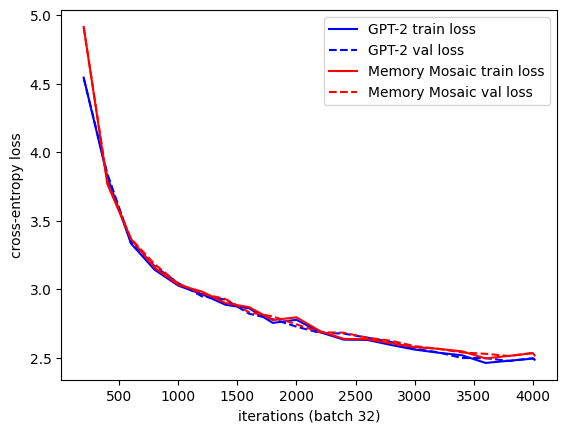

In [6]:
import matplotlib.pyplot as plt

for (name, log), c in zip(logs.items(), "br"):
    for split, style in ("train", "-"), ("val", "--"):
        plt.plot(list(log[split]), list(log[split].values()), c + style, label=f"{name} {split} loss")
plt.xlabel(f"iterations (batch {t_cfg.batch_size})")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.savefig("fig7_1block.png", dpi=150)